# Acceptance Rate Model — BẢN TỔNG HỢP (chạy 1 thể)

Gộp toàn bộ nội dung từ `01`–`04` vào một file. Chạy `Run All` là ra hết.

---

## 🎯 Yêu cầu gốc của mentor

> *"Nên maybe thử tìm cách model xem **khả năng chấp nhận giá của khách tăng hay giảm** knowing
> **giá đối thủ** và cả **thời tiết** nữa, **2 model**"*

Bối cảnh mentor nói thêm:

> *"...study 1 cái acceptance rate model hoàn toàn mới sẽ **khá mất tgian**"*
> *"Ở mấy cái public data này chắc tụi em ko access đc customer-level data đâu, nên cứ làm **global
> model** đc rồi"*

---

## 📑 Cấu trúc notebook — đọc kỹ phần này

| Phần | Nội dung | Có phải mentor yêu cầu? |
|---|---|---|
| **0–2** | Bối cảnh, hiệu chỉnh tham số, cơ chế model | Nền tảng bắt buộc |
| **3** | **MODEL 1** — chấp nhận theo giá đối thủ | ✅ **ĐÚNG YÊU CẦU** |
| **4** | **MODEL 2** — chấp nhận theo thời tiết | ✅ **ĐÚNG YÊU CẦU** |
| **5** | Độ nhạy — kết luận có vững không | Hỗ trợ 2 model trên |
| **6** | **Tóm tắt trả lời mentor** | ✅ **ĐÚNG YÊU CẦU** |
| **7–8** | Doanh thu, giá tối ưu, mô phỏng đầu-cuối | ⚠️ **MỞ RỘNG — không được yêu cầu** |
| **9** | Kết luận & hạn chế | |

> ⚠️ **Phần 7–8 là phần nhóm tự làm thêm**, không nằm trong yêu cầu của mentor. Khi báo cáo nên
> trình bày **Phần 3, 4, 6** trước; phần 7–8 chỉ đưa vào phụ lục hoặc nhắc tới nếu mentor quan tâm.

---

# PHẦN 0 — Giới hạn nền tảng: dữ liệu KHÔNG có nhãn accept/reject

Đã kiểm chứng bằng **3 cách độc lập**:

**(1) Generator khai báo thẳng** trong `generation_config.json`:
```
booking_or_completion_outcomes_generated    = False
event_level_production_rows_used_in_release = False
personalized_wrapper_enabled                = False
n_customers                                 = 20000   (có nhưng KHÔNG xuất ra)
```

**(2) Rà toàn bộ cột** — data dictionary 251 cột trên 8 bảng, tìm theo `accept|reject|outcome|
customer|rider|user` → **0 kết quả**.

**(3) Kiểm định placebo** — cầu có phản ứng với giá không?

| Biến | Lag | Tương quan riêng phần (t+k) | (t−k) | Kết luận |
|---|---:|---:|---:|---|
| Cầu | 5p | 0,0040 | 0,0050 | Đối xứng → không nhân quả |
| Cầu | 30p | 0,0100 | 0,0150 | Đối xứng → không nhân quả |
| Cung | 5p | 0,0475 | 0,0469 | Đối xứng → không nhân quả |

Tương quan ~0 và **đối xứng hoàn hảo** giữa tương lai/quá khứ ⇒ generator không mô phỏng phản ứng
hành vi với giá.

## Hệ quả: đây KHÔNG phải bài toán Machine Learning

| | Supervised | Unsupervised | **Cách làm ở đây** |
|---|---|---|---|
| Có nhãn `y`? | ✅ | ❌ | ❌ |
| Học từ dữ liệu? | ✅ | ✅ | ❌ **Không** |
| Nguồn tri thức | Dữ liệu | Dữ liệu | **Lý thuyết kinh tế** |

Đây là **structural modeling** — mô hình logit từ lý thuyết lựa chọn rời rạc (McFadden, Nobel 2000),
**không train**, chỉ hiệu chỉnh tham số. Vì vậy không có MAE/R²/accuracy; thay vào đó dùng **phân
tích độ nhạy** (Phần 5).

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline

# --- Okabe-Ito: an toan voi nguoi mu mau ---
BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK, LIGHT = "#222222", "#CCCCCC"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

# ══════════ MO HINH (toan bo "kien truc" chi co 4 dong nay) ══════════
P0 = 0.5            # muc chap nhan nen khi gia ngang bang doi thu   [GIA DINH]

def P_accept(ty_le_gia, eps, P0=P0, dich_WTP=0.0):
    """P(khach chap nhan). ty_le_gia = gia minh / gia doi thu."""
    b = eps / (1 - P0)                       # doi elasticity -> he so doc
    a = np.log(P0 / (1 - P0))                # muc nen
    return 1 / (1 + np.exp(-(a + b * (np.log(ty_le_gia) - np.log1p(dich_WTP)))))
# ═══════════════════════════════════════════════════════════════════

# Dai elasticity FIRM-level (canh tranh truc tiep voi doi thu)
EPS_F, EPS_CHINH = [-1.2, -2.0, -3.0], -2.0
# Dai elasticity MARKET-level (ca thi truong cung tang gia)
EPS_M = [-0.3, -0.5, -0.7]
# Cac moc doi gia
MOC = [-0.30, -0.25, -0.20, -0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
MOC_VE = [-0.30, -0.20, -0.10, 0.0, 0.10, 0.20, 0.30]

assert abs(P_accept(1.0, -2.0) - 0.5) < 1e-12
print("Mo hinh OK — tai gia ngang bang doi thu, P = 50% (dung theo thiet ke).")
print(f"Elasticity chinh: {EPS_CHINH} (firm-level) | dai do nhay: {EPS_F}")

Mo hinh OK — tai gia ngang bang doi thu, P = 50% (dung theo thiet ke).
Elasticity chinh: -2.0 (firm-level) | dai do nhay: [-1.2, -2.0, -3.0]


---

# PHẦN 1 — Hiệu chỉnh tham số **từ dữ liệu thật**

Model có 4 tham số. **Hai trong số đó đo được từ dữ liệu**, chỉ 2 cái là giả định.

**Ý tưởng:** hệ số nhân quan sát được chính là **giá cân bằng thị trường**. Nếu khi mưa thị trường
chấp nhận mức giá cao hơn X%, thì X% chính là mức dịch chuyển **sẵn sàng chi trả (WTP)**.

In [2]:
cols = ["target_request_id", "gio_vn", "weather_main", "target_shown_price", "target_shown_multiplier"]
d = pd.read_parquet("../../data/hcm_train_ready.parquet", columns=cols)
print(f"Nap {len(d):,} dong tho")
# Moi target_request_id xuat hien 4 lan (lag 5/10/15/30) voi CUNG gia/he so nhan
d = d.drop_duplicates(subset="target_request_id")
d["mua"] = d.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])
print(f"Sau khu trung lap theo target_request_id: {len(d):,} chuyen\n")

gm = d.groupby("mua").target_shown_multiplier.mean()
DICH_MUA = gm[True] / gm[False] - 1
gh = d.groupby("gio_vn").target_shown_multiplier.mean()
DICH_GIO = gh / gh.mean() - 1
GIA_DT = d.target_shown_price.median()

print(f"{'He so nhan khong mua':<28}: {gm[False]:.4f}")
print(f"{'He so nhan co mua':<28}: {gm[True]:.4f}")
print(f"{'=> DICH WTP do mua':<28}: {DICH_MUA*100:+.2f}%   [DO TU DU LIEU]")
print()
print(f"{'WTP thap nhat':<28}: {DICH_GIO.min()*100:+.1f}% (gio {DICH_GIO.idxmin()}h)")
print(f"{'WTP cao nhat':<28}: {DICH_GIO.max()*100:+.1f}% (gio {DICH_GIO.idxmax()}h)")
print(f"{'Bien do theo gio':<28}: {(gh.max()/gh.min()-1)*100:.1f}%   [DO TU DU LIEU]")
print()
print(f"{'Gia doi thu median':<28}: {GIA_DT:,.0f} d")

Nap 6,897,051 dong tho
Sau khu trung lap theo target_request_id: 1,724,714 chuyen



He so nhan khong mua        : 1.1414
He so nhan co mua           : 1.1940
=> DICH WTP do mua          : +4.61%   [DO TU DU LIEU]

WTP thap nhat               : -25.2% (gio 3h)
WTP cao nhat                : +12.2% (gio 18h)
Bien do theo gio            : 50.0%   [DO TU DU LIEU]

Gia doi thu median          : 114,000 d


| Tham số | Nguồn | Giá trị |
|---|---|---|
| Dịch WTP do **mưa** | 📊 **Đo từ dữ liệu** | **+4,61%** |
| Dịch WTP theo **giờ** | 📊 **Đo từ dữ liệu** | biên độ **50,0%** |
| Giá tham chiếu | 📊 Giá đối thủ trong dữ liệu | median **114k** |
| Elasticity `ε` | ⚠️ **Giả định** | −1,2 → −3,0 |
| Mức nền `P₀` | ⚠️ **Giả định** | 0,5 |

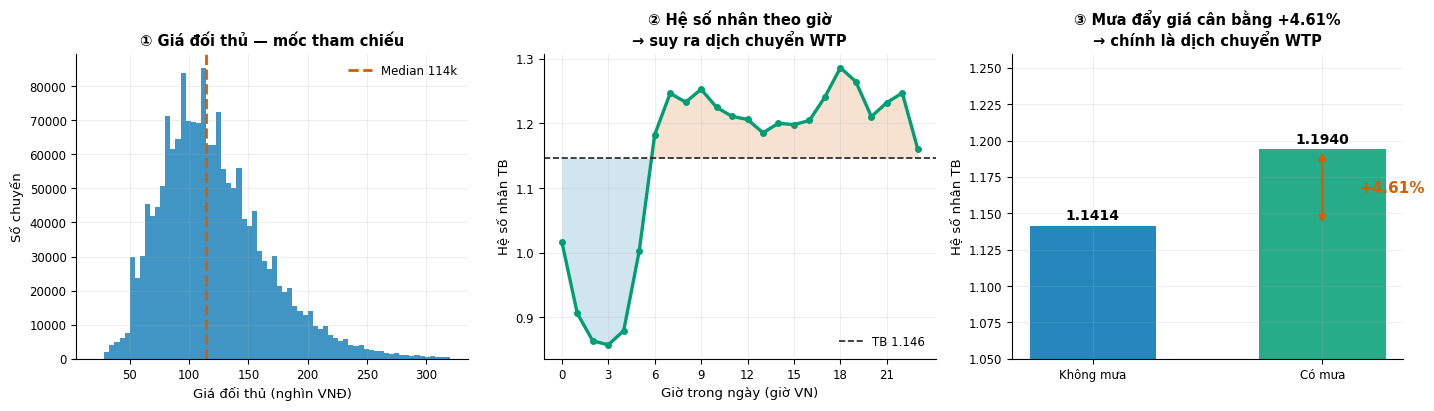

In [3]:
# ═════════ HINH AC1 — du lieu dau vao ═════════
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))

ax[0].hist(d.target_shown_price/1000, bins=70, range=(20, 320), color=BLUE, alpha=0.75, lw=0)
ax[0].axvline(GIA_DT/1000, color=RED, lw=2, ls="--", label=f"Median {GIA_DT/1000:.0f}k")
ax[0].set_xlabel("Giá đối thủ (nghìn VNĐ)"); ax[0].set_ylabel("Số chuyến")
ax[0].set_title("① Giá đối thủ — mốc tham chiếu", fontweight="bold"); ax[0].legend(frameon=False)

ax[1].plot(gh.index, gh.values, color=GREEN, lw=2.4, marker="o", ms=4)
ax[1].axhline(gh.mean(), color=INK, lw=1.2, ls="--", label=f"TB {gh.mean():.3f}")
ax[1].fill_between(gh.index, gh.mean(), gh.values, where=(gh.values >= gh.mean()),
                   color=RED, alpha=0.18, lw=0, interpolate=True)
ax[1].fill_between(gh.index, gh.mean(), gh.values, where=(gh.values < gh.mean()),
                   color=BLUE, alpha=0.18, lw=0, interpolate=True)
ax[1].set_xlabel("Giờ trong ngày (giờ VN)"); ax[1].set_ylabel("Hệ số nhân TB")
ax[1].set_title("② Hệ số nhân theo giờ\n→ suy ra dịch chuyển WTP", fontweight="bold")
ax[1].set_xticks(range(0, 24, 3)); ax[1].legend(frameon=False, loc="lower right")

bars = ax[2].bar(["Không mưa", "Có mưa"], [gm[False], gm[True]], color=[BLUE, GREEN],
                 alpha=0.85, width=0.55)
for b_, v in zip(bars, [gm[False], gm[True]]):
    ax[2].text(b_.get_x()+b_.get_width()/2, v+0.004, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
ax[2].set_ylim(1.05, gm[True]*1.055); ax[2].set_ylabel("Hệ số nhân TB")
ax[2].set_title(f"③ Mưa đẩy giá cân bằng {DICH_MUA*100:+.2f}%\n→ chính là dịch chuyển WTP", fontweight="bold")
ax[2].annotate("", xy=(1, gm[True]), xytext=(1, gm[False]),
               arrowprops=dict(arrowstyle="<->", color=RED, lw=2))
ax[2].text(1.16, (gm[True]+gm[False])/2, f"{DICH_MUA*100:+.2f}%", color=RED,
           fontsize=11, fontweight="bold", va="center")

plt.tight_layout(); plt.savefig(HINH / "AC1_du_lieu_dau_vao.png"); plt.show()

---

# PHẦN 2 — Cơ chế model hoạt động

$$P(\text{chấp nhận}) = \sigma\left(a + b \cdot \left[\log\frac{p}{p_{ref}} - \log(1+d)\right]\right)$$

| Tham số | Vai trò |
|---|---|
| `b = ε/(1−P₀)` | **độ dốc** — khách nhạy giá tới đâu |
| `a = logit(P₀)` | **chiều cao** tại điểm giá ngang bằng |
| `d` = dịch WTP | **vị trí ngang** — bối cảnh dịch cả đường cong |

**Vì sao dùng tỷ lệ `p/p_ref`:** khách không đánh giá "114k đắt hay rẻ" tuyệt đối, mà so với **lựa
chọn thay thế** (giá đối thủ) tại đúng thời điểm đó.

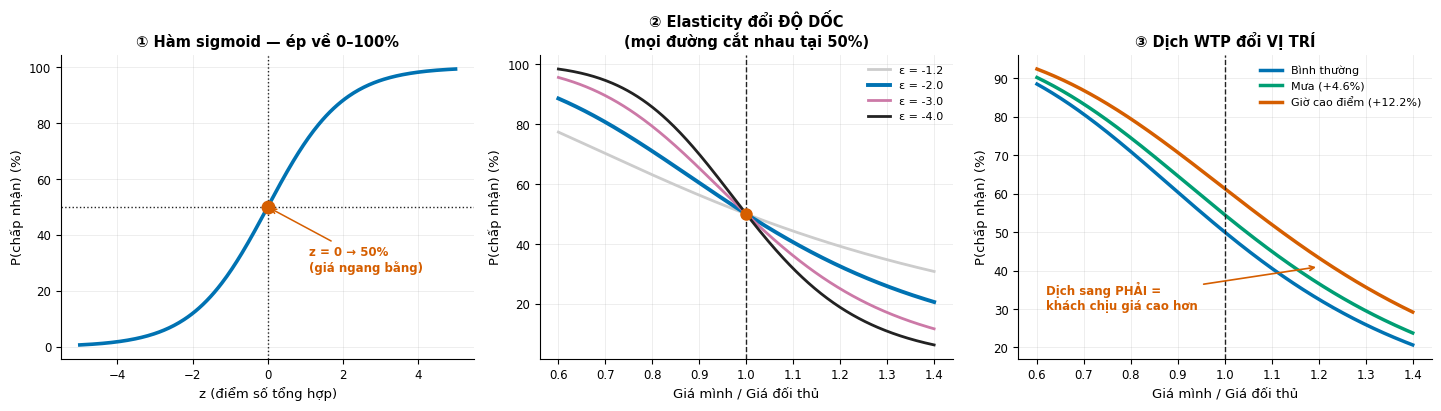

In [4]:
# ═════════ HINH AC2 — co che model ═════════
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
r = np.linspace(0.6, 1.4, 300)

z = np.linspace(-5, 5, 300)
ax[0].plot(z, 1/(1+np.exp(-z))*100, color=BLUE, lw=2.6)
ax[0].axhline(50, color=INK, lw=1, ls=":"); ax[0].axvline(0, color=INK, lw=1, ls=":")
ax[0].plot(0, 50, "o", color=RED, ms=9, zorder=5)
ax[0].annotate("z = 0 → 50%\n(giá ngang bằng)", xy=(0, 50), xytext=(1.1, 27),
               fontsize=8.5, fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.1))
ax[0].set_xlabel("z (điểm số tổng hợp)"); ax[0].set_ylabel("P(chấp nhận) (%)")
ax[0].set_title("① Hàm sigmoid — ép về 0–100%", fontweight="bold")

for e, col, lw in zip([-1.2, -2.0, -3.0, -4.0], [LIGHT, BLUE, PURPLE, INK], [2, 2.8, 2, 2]):
    ax[1].plot(r, P_accept(r, e)*100, color=col, lw=lw, label=f"ε = {e}")
ax[1].axvline(1.0, color=INK, lw=1, ls="--"); ax[1].plot(1.0, 50, "o", color=RED, ms=8, zorder=5)
ax[1].set_xlabel("Giá mình / Giá đối thủ"); ax[1].set_ylabel("P(chấp nhận) (%)")
ax[1].set_title("② Elasticity đổi ĐỘ DỐC\n(mọi đường cắt nhau tại 50%)", fontweight="bold")
ax[1].legend(frameon=False, fontsize=8)

for dd, col, ten in zip([0.0, DICH_MUA, DICH_GIO.max()], [BLUE, GREEN, RED],
                        ["Bình thường", f"Mưa ({DICH_MUA*100:+.1f}%)",
                         f"Giờ cao điểm ({DICH_GIO.max()*100:+.1f}%)"]):
    ax[2].plot(r, P_accept(r, EPS_CHINH, dich_WTP=dd)*100, color=col, lw=2.5, label=ten)
ax[2].axvline(1.0, color=INK, lw=1, ls="--")
ax[2].annotate("Dịch sang PHẢI =\nkhách chịu giá cao hơn", xy=(1.20, 41), xytext=(0.62, 30),
               fontsize=8.5, fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
ax[2].set_xlabel("Giá mình / Giá đối thủ"); ax[2].set_ylabel("P(chấp nhận) (%)")
ax[2].set_title("③ Dịch WTP đổi VỊ TRÍ", fontweight="bold")
ax[2].legend(frameon=False, fontsize=8, loc="upper right")

plt.tight_layout(); plt.savefig(HINH / "AC2_co_che_model.png"); plt.show()

---
---

# ✅ PHẦN 3 — MODEL 1: chấp nhận theo **GIÁ ĐỐI THỦ**

> ### Đây là câu trả lời trực tiếp cho yêu cầu mentor

Phải tách **2 tình huống** vì chúng cho kết luận **ngược nhau**:

| | Tình huống | Khách làm gì | Elasticity |
|---|---|---|---|
| **3A** | **Cả thị trường** cùng tăng giá | Chỉ *đi* hoặc *không đi* | Market −0,3 → −0,7 |
| **3B** | **Chỉ mình** tăng, đối thủ giữ nguyên | **Chuyển sang đối thủ** | Firm −1,2 → −3,0 |

## 3A. Cả thị trường cùng tăng giá — dùng để hiệu chỉnh elasticity

Đây đúng tình huống thí nghiệm classical algo của mentor (*"tăng gần 10% GMV"*).

In [5]:
rows = []
for p in [m for m in MOC if m > 0]:
    r_ = {"tang_gia": f"+{p*100:.0f}%"}
    for e in EPS_M:
        r_[f"San luong (ε={e})"] = f"{((1+p)**e - 1)*100:+.1f}%"
        r_[f"GMV (ε={e})"] = f"{((1+p)**(1+e) - 1)*100:+.1f}%"
    rows.append(r_)
print("BANG 3A — CA THI TRUONG cung tang gia")
display(pd.DataFrame(rows).set_index("tang_gia"))
print("Doc: eps=-0.5, tang gia 20% -> mat 8.7% so cuoc nhung GMV van +9.5%")
print("     Vi |eps| < 1: san luong giam CHAM HON gia tang.\n")

print("SUY NGUOC ELASTICITY tu bang chung GMV +10% cua mentor:")
print(f"{'gia tang':>10} {'=> eps_M':>10} {'GMV':>9} {'san luong':>12}")
print("-" * 46)
for p_t in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
    e = np.log(1.10/(1+p_t)) / np.log(1+p_t)
    print(f"{p_t*100:9.0f}% {e:10.2f} {((1+p_t)**(1+e)-1)*100:+8.1f}% {((1+p_t)**e-1)*100:+11.1f}%")
print("\n=> Chi can hoi mentor GIA TANG BAO NHIEU %, khong can hoi elasticity truc tiep.")

BANG 3A — CA THI TRUONG cung tang gia


,San luong (ε=-0.3),GMV (ε=-0.3),San luong (ε=-0.5),GMV (ε=-0.5),San luong (ε=-0.7),GMV (ε=-0.7)
tang_gia,,,,,,
+5%,-1.5%,+3.5%,-2.4%,+2.5%,-3.4%,+1.5%
+10%,-2.8%,+6.9%,-4.7%,+4.9%,-6.5%,+2.9%
+15%,-4.1%,+10.3%,-6.7%,+7.2%,-9.3%,+4.3%
+20%,-5.3%,+13.6%,-8.7%,+9.5%,-12.0%,+5.6%
+25%,-6.5%,+16.9%,-10.6%,+11.8%,-14.5%,+6.9%
+30%,-7.6%,+20.2%,-12.3%,+14.0%,-16.8%,+8.2%


Doc: eps=-0.5, tang gia 20% -> mat 8.7% so cuoc nhung GMV van +9.5%
     Vi |eps| < 1: san luong giam CHAM HON gia tang.

SUY NGUOC ELASTICITY tu bang chung GMV +10% cua mentor:
  gia tang   => eps_M       GMV    san luong
----------------------------------------------
       10%       0.00    +10.0%        +0.0%
       15%      -0.32    +10.0%        -4.3%
       20%      -0.48    +10.0%        -8.3%
       25%      -0.57    +10.0%       -12.0%
       30%      -0.64    +10.0%       -15.4%
       40%      -0.72    +10.0%       -21.4%

=> Chi can hoi mentor GIA TANG BAO NHIEU %, khong can hoi elasticity truc tiep.


## 3B. Chỉ mình đổi giá — **đây là câu trả lời chính**

### ⭐ Cách trình bày: dùng **% thay đổi tương đối**, không dùng mức tuyệt đối

Mức tuyệt đối (VD *"chấp nhận = 40,6%"*) phụ thuộc nặng vào giả định `P₀`. Đã kiểm chứng bằng cách
cho `P₀` chạy từ 0,30 đến 0,70:

| Cách báo cáo | Ví dụ | Dao động khi đổi `P₀` |
|---|---|---:|
| Mức tuyệt đối | *"chấp nhận = 40,6%"* | **30,7 điểm** ❌ |
| Thay đổi tuyệt đối | *"giảm 9,4 điểm %"* | 9,3 điểm ⚠️ |
| **Thay đổi tương đối** | *"giảm 19%"* | **3,1 điểm** ✅ |

→ Cách tương đối **ổn định gấp 10 lần**. Nên mọi kết luận đều phát biểu theo dạng này.

In [6]:
rows = []
for p in MOC:
    r_ = {"doi_gia": f"{p*100:+.0f}%"}
    for e in EPS_F:
        P = P_accept(1+p, e)
        r_[f"P(accept) ε={e}"] = f"{P*100:.1f}%"
        r_[f"Δ ε={e}"] = f"{(P-P0)*100:+.1f}đ"
    rows.append(r_)
print("BANG 3B — KHA NANG CHAP NHAN khi minh doi gia so voi doi thu")
print("('d' = diem phan tram)")
display(pd.DataFrame(rows).set_index("doi_gia"))

# ===== BANG CHINH: % THAY DOI TUONG DOI (it phu thuoc P0 nhat) =====
P0_KIEM = [0.30, 0.40, 0.50, 0.60, 0.70]     # dai P0 de kiem tra do on dinh

def doi_tuong_doi(p, eps, P0_):
    return P_accept(1+p, eps, P0_) / P_accept(1.0, eps, P0_) - 1

rows = []
for p in MOC:
    r_ = {"doi_gia": f"{p*100:+.0f}%"}
    for e in EPS_F:
        vals = [doi_tuong_doi(p, e, x) for x in P0_KIEM]
        r_[f"eps={e}"] = f"{np.mean(vals)*100:+.1f}%"
    rows.append(r_)
print("BANG CHINH — % THAY DOI TUONG DOI cua kha nang chap nhan")
print("(trung binh tren P0 = 0.30..0.70; chenh lech giua cac P0 rat nho)")
display(pd.DataFrame(rows).set_index("doi_gia"))

print("=" * 70)
print("TRA LOI MENTOR — MODEL 1")
print("=" * 70)
for p in [0.05, 0.10, 0.20]:
    vals = [doi_tuong_doi(p, EPS_CHINH, x) for x in P0_KIEM]
    print(f"  Tang gia {p*100:+.0f}% so voi doi thu -> kha nang chap nhan GIAM "
          f"{abs(np.mean(vals))*100:.0f}%  (dao dong {min(vals)*100:+.1f}%..{max(vals)*100:+.1f}%)")
print()
for p in [-0.05, -0.10, -0.20]:
    vals = [doi_tuong_doi(p, EPS_CHINH, x) for x in P0_KIEM]
    print(f"  Giam gia {p*100:+.0f}% so voi doi thu -> kha nang chap nhan TANG "
          f"{np.mean(vals)*100:.0f}%  (dao dong {min(vals)*100:+.1f}%..{max(vals)*100:+.1f}%)")

BANG 3B — KHA NANG CHAP NHAN khi minh doi gia so voi doi thu
('d' = diem phan tram)


,P(accept) ε=-1.2,Δ ε=-1.2,P(accept) ε=-2.0,Δ ε=-2.0,P(accept) ε=-3.0,Δ ε=-3.0
doi_gia,,,,,,
-30%,70.2%,+20.2đ,80.6%,+30.6đ,89.5%,+39.5đ
-25%,66.6%,+16.6đ,76.0%,+26.0đ,84.9%,+34.9đ
-20%,63.1%,+13.1đ,70.9%,+20.9đ,79.2%,+29.2đ
-15%,59.6%,+9.6đ,65.7%,+15.7đ,72.6%,+22.6đ
-10%,56.3%,+6.3đ,60.4%,+10.4đ,65.3%,+15.3đ
-5%,53.1%,+3.1đ,55.1%,+5.1đ,57.6%,+7.6đ
+0%,50.0%,+0.0đ,50.0%,+0.0đ,50.0%,+0.0đ
+5%,47.1%,-2.9đ,45.1%,-4.9đ,42.7%,-7.3đ
+10%,44.3%,-5.7đ,40.6%,-9.4đ,36.1%,-13.9đ


BANG CHINH — % THAY DOI TUONG DOI cua kha nang chap nhan
(trung binh tren P0 = 0.30..0.70; chenh lech giua cac P0 rat nho)


,eps=-1.2,eps=-2.0,eps=-3.0
doi_gia,,,
-30%,+39.3%,+60.2%,+80.1%
-25%,+32.4%,+50.7%,+69.4%
-20%,+25.6%,+40.8%,+57.3%
-15%,+18.9%,+30.7%,+44.1%
-10%,+12.4%,+20.4%,+29.9%
-5%,+6.1%,+10.1%,+15.1%
+0%,+0.0%,+0.0%,+0.0%
+5%,-5.9%,-9.8%,-14.7%
+10%,-11.5%,-19.2%,-28.5%


TRA LOI MENTOR — MODEL 1
  Tang gia +5% so voi doi thu -> kha nang chap nhan GIAM 10%  (dao dong -10.3%..-9.5%)
  Tang gia +10% so voi doi thu -> kha nang chap nhan GIAM 19%  (dao dong -21.0%..-18.0%)
  Tang gia +20% so voi doi thu -> kha nang chap nhan GIAM 36%  (dao dong -41.6%..-32.4%)

  Giam gia -5% so voi doi thu -> kha nang chap nhan TANG 10%  (dao dong +9.5%..+10.5%)
  Giam gia -10% so voi doi thu -> kha nang chap nhan TANG 20%  (dao dong +17.8%..+22.2%)
  Giam gia -20% so voi doi thu -> kha nang chap nhan TANG 41%  (dao dong +30.2%..+49.3%)


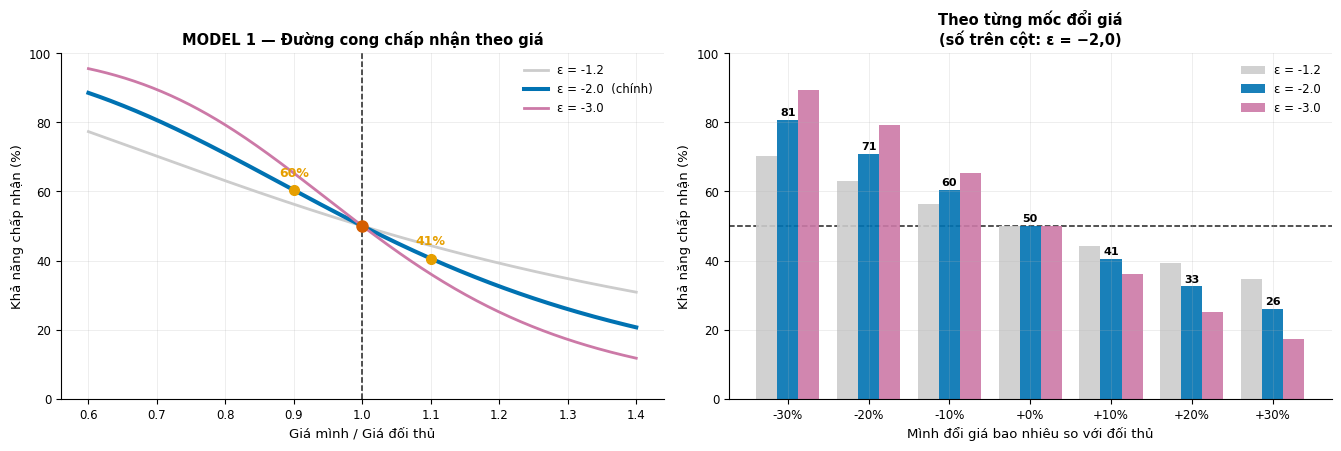

In [7]:
# ═════════ HINH AC3 — MODEL 1 ═════════
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))

for e, col, lw in zip(EPS_F, [LIGHT, BLUE, PURPLE], [2, 2.9, 2]):
    ax[0].plot(r, P_accept(r, e)*100, color=col, lw=lw,
               label=f"ε = {e}" + ("  (chính)" if e == EPS_CHINH else ""))
ax[0].axvline(1.0, color=INK, lw=1.1, ls="--"); ax[0].plot(1.0, 50, "o", color=RED, ms=8, zorder=6)
for p_ in [0.9, 1.1]:
    v = P_accept(p_, EPS_CHINH)*100
    ax[0].plot(p_, v, "o", color=ORANGE, ms=7, zorder=6)
    ax[0].text(p_, v+4, f"{v:.0f}%", ha="center", fontsize=9, fontweight="bold", color=ORANGE)
ax[0].set_xlabel("Giá mình / Giá đối thủ"); ax[0].set_ylabel("Khả năng chấp nhận (%)")
ax[0].set_title("MODEL 1 — Đường cong chấp nhận theo giá", fontweight="bold")
ax[0].legend(frameon=False); ax[0].set_ylim(0, 100)

x = np.arange(len(MOC_VE)); w = 0.26
for k, (e, col) in enumerate(zip(EPS_F, [LIGHT, BLUE, PURPLE])):
    vals = [P_accept(1+p, e)*100 for p in MOC_VE]
    b_ = ax[1].bar(x + (k-1)*w, vals, w, color=col, alpha=0.9, label=f"ε = {e}")
    if e == EPS_CHINH:
        for bb, v in zip(b_, vals):
            ax[1].text(bb.get_x()+bb.get_width()/2, v+1.2, f"{v:.0f}", ha="center",
                       fontsize=8, fontweight="bold")
ax[1].axhline(P0*100, color=INK, lw=1.1, ls="--", zorder=0)
ax[1].set_xticks(x); ax[1].set_xticklabels([f"{p*100:+.0f}%" for p in MOC_VE])
ax[1].set_xlabel("Mình đổi giá bao nhiêu so với đối thủ")
ax[1].set_ylabel("Khả năng chấp nhận (%)")
ax[1].set_title("Theo từng mốc đổi giá\n(số trên cột: ε = −2,0)", fontweight="bold")
ax[1].legend(frameon=False); ax[1].set_ylim(0, 100)

plt.tight_layout(); plt.savefig(HINH / "AC3_model1_gia.png"); plt.show()

---
---

# ✅ PHẦN 4 — MODEL 2: chấp nhận theo **THỜI TIẾT**

> ### Đây là câu trả lời trực tiếp thứ hai cho mentor

**Cơ chế:** mưa → lựa chọn thay thế (đi bộ, xe buýt, xe máy) kém hấp dẫn → WTP tăng → tại **cùng
mức giá**, khả năng chấp nhận **tăng**.

Mức dịch chuyển WTP **đo từ dữ liệu: +4,61%** (không phải giả định).

In [8]:
rows = []
for p in MOC:
    P_k = P_accept(1+p, EPS_CHINH, dich_WTP=0.0)
    P_m = P_accept(1+p, EPS_CHINH, dich_WTP=DICH_MUA)
    rows.append({"doi_gia": f"{p*100:+.0f}%", "khong_mua": f"{P_k*100:.1f}%",
                 "co_mua": f"{P_m*100:.1f}%", "chenh": f"{(P_m-P_k)*100:+.2f}đ"})
print(f"BANG 4 — Anh huong THOI TIET tai tung moc gia (eps = {EPS_CHINH})")
display(pd.DataFrame(rows).set_index("doi_gia"))

P_k0 = P_accept(1.0, EPS_CHINH, dich_WTP=0.0)
P_m0 = P_accept(1.0, EPS_CHINH, dich_WTP=DICH_MUA)
print("=" * 70)
print("TRA LOI MENTOR — MODEL 2")
print("=" * 70)
print(f"  Tai gia ngang bang doi thu:")
print(f"    Khong mua : {P_k0*100:.2f}%")
print(f"    Co mua    : {P_m0*100:.2f}%   -> chap nhan TANG {(P_m0-P_k0)*100:+.2f} diem %")
print()
print(f"  Y nghia van hanh: khi mua co the TANG GIA them ~{DICH_MUA*100:.1f}%")
print(f"                    ma van GIU NGUYEN ty le chap nhan.")

BANG 4 — Anh huong THOI TIET tai tung moc gia (eps = -2.0)


,khong_mua,co_mua,chenh
doi_gia,,,
-30%,80.6%,83.3%,+2.66đ
-25%,76.0%,79.1%,+3.14đ
-20%,70.9%,74.5%,+3.57đ
-15%,65.7%,69.6%,+3.94đ
-10%,60.4%,64.6%,+4.22đ
-5%,55.1%,59.5%,+4.41đ
+0%,50.0%,54.5%,+4.49đ
+5%,45.1%,49.6%,+4.49đ
+10%,40.6%,45.0%,+4.41đ


TRA LOI MENTOR — MODEL 2
  Tai gia ngang bang doi thu:
    Khong mua : 50.00%
    Co mua    : 54.49%   -> chap nhan TANG +4.49 diem %

  Y nghia van hanh: khi mua co the TANG GIA them ~4.6%
                    ma van GIU NGUYEN ty le chap nhan.


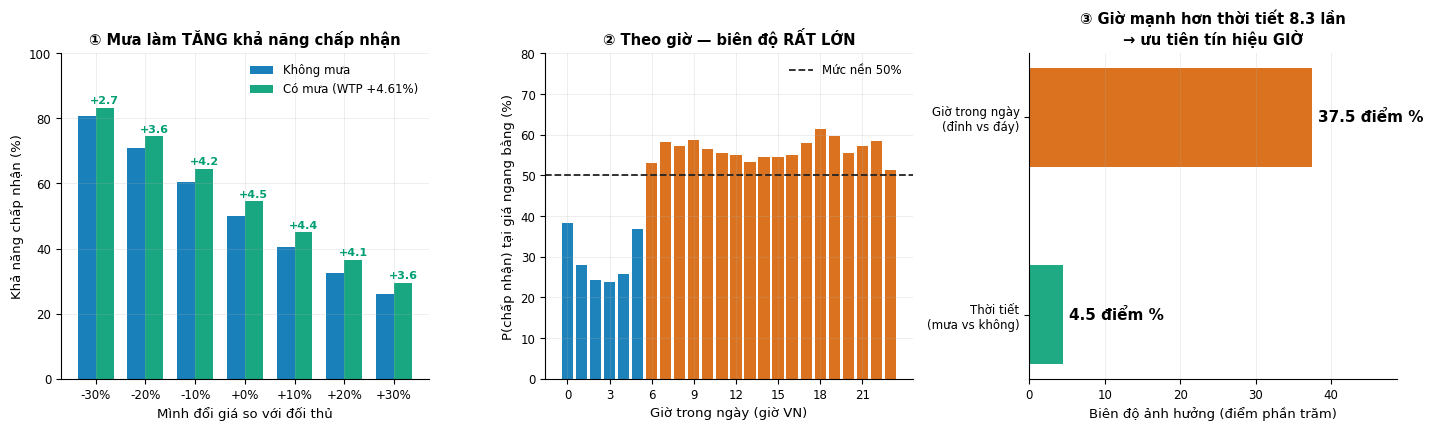

Bien do mua: 4.49 diem % | bien do gio: 37.48 diem % -> gap 8.3 lan


In [9]:
# ═════════ HINH AC4 — MODEL 2 ═════════
def khung(h):
    if h < 5:  return 0
    if h < 7:  return 1
    if h < 9:  return 2
    if h < 16: return 3
    if h < 19: return 4
    return 5
TEN = ["Đêm khuya\n(0-5h)", "Sáng sớm\n(5-7h)", "Cao điểm sáng\n(7-9h)",
       "Giữa ngày\n(9-16h)", "Cao điểm chiều\n(16-19h)", "Tối\n(19-24h)"]
dich_khung = [np.mean([DICH_GIO[h] for h in range(24) if khung(h) == k]) for k in range(6)]

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

x2 = np.arange(len(MOC_VE)); w2 = 0.36
v_kho = [P_accept(1+p, EPS_CHINH, dich_WTP=0.0)*100 for p in MOC_VE]
v_mua = [P_accept(1+p, EPS_CHINH, dich_WTP=DICH_MUA)*100 for p in MOC_VE]
ax[0].bar(x2 - w2/2, v_kho, w2, color=BLUE, alpha=0.9, label="Không mưa")
b2 = ax[0].bar(x2 + w2/2, v_mua, w2, color=GREEN, alpha=0.9, label=f"Có mưa (WTP {DICH_MUA*100:+.2f}%)")
for bb, v1, v2 in zip(b2, v_kho, v_mua):
    ax[0].text(bb.get_x()+bb.get_width()/2, v2+1.2, f"+{v2-v1:.1f}", ha="center",
               fontsize=8, color=GREEN, fontweight="bold")
ax[0].set_xticks(x2); ax[0].set_xticklabels([f"{p*100:+.0f}%" for p in MOC_VE])
ax[0].set_xlabel("Mình đổi giá so với đối thủ"); ax[0].set_ylabel("Khả năng chấp nhận (%)")
ax[0].set_title("① Mưa làm TĂNG khả năng chấp nhận", fontweight="bold")
ax[0].legend(frameon=False); ax[0].set_ylim(0, 100)

Pg = np.array([P_accept(1.0, EPS_CHINH, dich_WTP=DICH_GIO[h])*100 for h in range(24)])
ax[1].bar(range(24), Pg, color=[RED if v > 50 else BLUE for v in Pg], alpha=0.88)
ax[1].axhline(50, color=INK, lw=1.3, ls="--", label="Mức nền 50%")
ax[1].set_xlabel("Giờ trong ngày (giờ VN)"); ax[1].set_ylabel("P(chấp nhận) tại giá ngang bằng (%)")
ax[1].set_title("② Theo giờ — biên độ RẤT LỚN", fontweight="bold")
ax[1].set_xticks(range(0, 24, 3)); ax[1].legend(frameon=False); ax[1].set_ylim(0, 80)

bd_gio, bd_mua = Pg.max() - Pg.min(), (P_m0 - P_k0)*100
bb = ax[2].barh(["Thời tiết\n(mưa vs không)", "Giờ trong ngày\n(đỉnh vs đáy)"],
                [bd_mua, bd_gio], color=[GREEN, RED], alpha=0.88, height=0.5)
for b_, v in zip(bb, [bd_mua, bd_gio]):
    ax[2].text(v+0.8, b_.get_y()+b_.get_height()/2, f"{v:.1f} điểm %", va="center",
               fontsize=11, fontweight="bold")
ax[2].set_xlabel("Biên độ ảnh hưởng (điểm phần trăm)")
ax[2].set_title(f"③ Giờ mạnh hơn thời tiết {bd_gio/bd_mua:.1f} lần\n→ ưu tiên tín hiệu GIỜ",
                fontweight="bold")
ax[2].set_xlim(0, bd_gio*1.3); ax[2].grid(axis="y", alpha=0)

plt.tight_layout(); plt.savefig(HINH / "AC4_model2_thoitiet.png"); plt.show()
print(f"Bien do mua: {bd_mua:.2f} diem % | bien do gio: {bd_gio:.2f} diem % -> gap {bd_gio/bd_mua:.1f} lan")

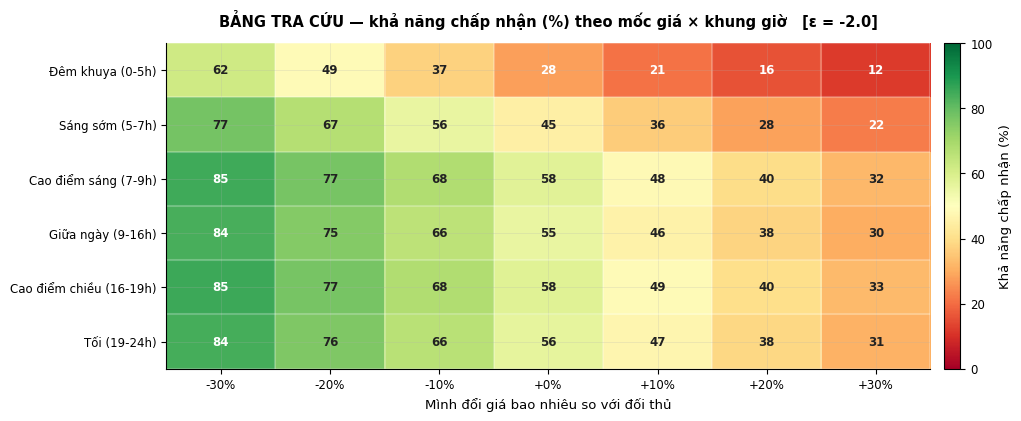

In [10]:
# ═════════ HINH AC5 — bang tra cuu gop 2 model ═════════
M = np.array([[P_accept(1+p, EPS_CHINH, dich_WTP=dd)*100 for p in MOC_VE] for dd in dich_khung])
fig, ax = plt.subplots(figsize=(11, 4.3))
im = ax.imshow(M, cmap="RdYlGn", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(MOC_VE))); ax.set_xticklabels([f"{p*100:+.0f}%" for p in MOC_VE])
ax.set_yticks(range(6)); ax.set_yticklabels([t.replace("\n", " ") for t in TEN], fontsize=8.5)
ax.set_xlabel("Mình đổi giá bao nhiêu so với đối thủ")
ax.set_title(f"BẢNG TRA CỨU — khả năng chấp nhận (%) theo mốc giá × khung giờ   [ε = {EPS_CHINH}]",
             fontweight="bold", pad=12)
for i in range(6):
    for j in range(len(MOC_VE)):
        ax.text(j, i, f"{M[i,j]:.0f}", ha="center", va="center", fontsize=8.5,
                color="white" if (M[i,j] < 28 or M[i,j] > 78) else INK, fontweight="bold")
ax.set_xticks(np.arange(-.5, len(MOC_VE), 1), minor=True)
ax.set_yticks(np.arange(-.5, 6, 1), minor=True)
ax.grid(which="minor", color="white", lw=1.5); ax.tick_params(which="minor", length=0)
plt.colorbar(im, ax=ax, label="Khả năng chấp nhận (%)", pad=0.015)
plt.tight_layout(); plt.savefig(HINH / "AC5_bang_tracuu.png"); plt.show()

---

# PHẦN 5 — Độ nhạy: kết luận có **vững** không?

Vì `ε` và `P₀` là giả định, phải kiểm tra kết luận có đổi chiều khi thay đổi chúng không.

In [11]:
rows = []
for e in EPS_F:
    P_k = P_accept(1.0, e, dich_WTP=0.0); P_m = P_accept(1.0, e, dich_WTP=DICH_MUA)
    Pg_ = np.array([P_accept(1.0, e, dich_WTP=dd) for dd in dich_khung])
    rows.append({
        "elasticity": e,
        "tang_gia_10%_→_chap_nhan": f"{P_accept(1.10, e)*100:.1f}%",
        "chap_nhan_GIAM?": "CO" if P_accept(1.10, e) < P0 else "KHONG",
        "mua_tang_(diem%)": round((P_m-P_k)*100, 2),
        "mua_lam_TANG?": "CO" if P_m > P_k else "KHONG",
        "bien_do_gio_(diem%)": round((Pg_.max()-Pg_.min())*100, 2),
        "gio_manh_hon_mua?": "CO" if (Pg_.max()-Pg_.min()) > (P_m-P_k) else "KHONG",
    })
ds = pd.DataFrame(rows)
display(ds)

print("KIEM TRA TINH VUNG — 3 ket luan chinh:")
print(f"  1. Gia cao hon doi thu -> chap nhan GIAM : {ds['chap_nhan_GIAM?'].eq('CO').sum()}/{len(ds)}")
print(f"  2. Mua lam TANG kha nang chap nhan       : {ds['mua_lam_TANG?'].eq('CO').sum()}/{len(ds)}")
print(f"  3. Gio tac dong manh hon thoi tiet       : {ds['gio_manh_hon_mua?'].eq('CO').sum()}/{len(ds)}")
print("\n-> Ca 3 ket luan KHONG phu thuoc gia tri elasticity cu the.")

,elasticity,tang_gia_10%_→_chap_nhan,chap_nhan_GIAM?,mua_tang_(diem%),mua_lam_TANG?,bien_do_gio_(diem%),gio_manh_hon_mua?
0,-1.2,44.3%,CO,2.70,CO,18.72,CO
1,-2.0,40.6%,CO,4.49,CO,30.15,CO
2,-3.0,36.1%,CO,6.72,CO,42.56,CO


KIEM TRA TINH VUNG — 3 ket luan chinh:
  1. Gia cao hon doi thu -> chap nhan GIAM : 3/3
  2. Mua lam TANG kha nang chap nhan       : 3/3
  3. Gio tac dong manh hon thoi tiet       : 3/3

-> Ca 3 ket luan KHONG phu thuoc gia tri elasticity cu the.


---
---

# ✅ PHẦN 6 — TÓM TẮT TRẢ LỜI MENTOR

> ### Đây là phần cần trình bày với mentor

In [12]:
print("╔" + "═"*72 + "╗")
print("║" + " TRA LOI YEU CAU: 2 MODEL XU HUONG ACCEPTANCE ".center(72) + "║")
print("╚" + "═"*72 + "╝")
print()
print("MODEL 1 — Khi biet GIA DOI THU:")
print("─" * 74)
print("  (bao cao theo % THAY DOI TUONG DOI — it phu thuoc gia dinh P0 nhat)")
print()
print("  Gia minh CAO hon doi thu  ->  kha nang chap nhan GIAM")
for p in [0.05, 0.10, 0.20]:
    v = np.mean([doi_tuong_doi(p, EPS_CHINH, x) for x in P0_KIEM])
    print(f"      +{p*100:.0f}%  ->  giam {abs(v)*100:.0f}%")
print()
print("  Gia minh THAP hon doi thu ->  kha nang chap nhan TANG")
for p in [-0.05, -0.10, -0.20]:
    v = np.mean([doi_tuong_doi(p, EPS_CHINH, x) for x in P0_KIEM])
    print(f"      {p*100:.0f}%  ->  tang {v*100:.0f}%")
print()
print()
print("MODEL 2 — Khi biet THOI TIET:")
print("─" * 74)
print(f"  Troi MUA  ->  kha nang chap nhan TANG {(P_m0-P_k0)*100:+.2f} diem %")
print(f"                (tuong duong: tang gia duoc ~{DICH_MUA*100:.1f}% ma khong mat khach)")
print()
print(f"  So sanh do lon:")
print(f"      Thoi tiet (mua vs khong) : {bd_mua:5.2f} diem %")
print(f"      Gio     (dinh vs day)    : {bd_gio:5.2f} diem %   <- manh hon {bd_gio/bd_mua:.1f} lan")
print()
print()
print("3 KET LUAN VUNG tren toan dai gia dinh (3/3 truong hop):")
print("─" * 74)
print("  1. Gia cao hon doi thu -> chap nhan GIAM")
print("  2. Mua -> chap nhan TANG")
print("  3. GIO tac dong manh hon THOI TIET nhieu lan")
print()
print("LUU Y BAT BUOC NEU trinh bay:")
print("  Day la MO PHONG theo gia dinh elasticity, KHONG phai model hoc tu du lieu.")
print("  Du lieu khong co nhan accept/reject (da kiem chung 3 cach).")

╔════════════════════════════════════════════════════════════════════════╗
║              TRA LOI YEU CAU: 2 MODEL XU HUONG ACCEPTANCE              ║
╚════════════════════════════════════════════════════════════════════════╝

MODEL 1 — Khi biet GIA DOI THU:
──────────────────────────────────────────────────────────────────────────
  (bao cao theo % THAY DOI TUONG DOI — it phu thuoc gia dinh P0 nhat)

  Gia minh CAO hon doi thu  ->  kha nang chap nhan GIAM
      +5%  ->  giam 10%
      +10%  ->  giam 19%
      +20%  ->  giam 36%

  Gia minh THAP hon doi thu ->  kha nang chap nhan TANG
      -5%  ->  tang 10%
      -10%  ->  tang 20%
      -20%  ->  tang 41%


MODEL 2 — Khi biet THOI TIET:
──────────────────────────────────────────────────────────────────────────
  Troi MUA  ->  kha nang chap nhan TANG +4.49 diem %
                (tuong duong: tang gia duoc ~4.6% ma khong mat khach)

  So sanh do lon:
      Thoi tiet (mua vs khong) :  4.49 diem %
      Gio     (dinh vs day)    : 37.48 d

### Câu hỏi nên gửi mentor

| # | Câu hỏi | Vì sao cần |
|---|---|---|
| 1 | Thí nghiệm classical algo (+10% GMV) — **giá tăng trung bình bao nhiêu %**? | Chốt được `ε_market` thật (bảng 3A) |
| 2 | **Thị phần** XanhSM so với đối thủ chính? | Quy `ε_market` → `ε_firm` |
| 3 | Tỷ lệ khách xem giá rồi **không đặt** (`P₀`)? | Tham số **nhạy nhất** của model |
| 4 | Hệ thống có log **lần hiển thị giá mà khách không đặt** không? | Điều kiện để làm supervised sau này |
| 5 | Outcome có tách được **`no_driver_found`** khỏi khách chủ động không đặt? | Tránh học nhầm |

---
---
---

# ⚠️ PHẦN 7 — MỞ RỘNG: doanh thu & giá tối ưu

> **CẢNH BÁO PHẠM VI:** từ đây trở xuống là phần nhóm **tự làm thêm**, mentor **KHÔNG yêu cầu**.
>
> Mentor chỉ hỏi *"acceptance tăng hay giảm"* (Phần 3, 4, 6 đã trả lời xong). Phần này đi thêm một
> bước: *nếu biết acceptance thì nên báo giá bao nhiêu*.
>
> **Rủi ro:** phần này phải giả định thêm `P₀ = 0,5` — mà `P₀` là tham số nhạy nhất. Nên khi báo cáo
> chỉ nêu nếu mentor quan tâm, không để lấn át câu trả lời chính.

In [13]:
def ty_le_toi_uu(eps, P0=P0):
    rr = np.linspace(0.40, 1.60, 4000)
    return rr[int(np.argmax(rr * P_accept(rr, eps, P0)))]

R_STAR = ty_le_toi_uu(EPS_CHINH)
print(f"Ty le gia toi uu doanh thu: {R_STAR:.4f}x gia doi thu\n")

rows = []
for e in EPS_F:
    rs = ty_le_toi_uu(e)
    P = P_accept(rs, e)
    R = rs * P / (1.0 * P_accept(1.0, e))
    rows.append({"elasticity": e, "gia_toi_uu": f"{rs:.3f}x",
                 "P(chap nhan)": f"{P*100:.1f}%",
                 "doanh_thu_vs_ngang_bang": f"{(R-1)*100:+.1f}%",
                 "toi_uu < 1?": "CO" if rs < 1 else "KHONG"})
display(pd.DataFrame(rows))
print(f"-> Gia toi uu LUON thap hon gia doi thu ({sum(1 for x in rows if x['toi_uu < 1?']=='CO')}/{len(rows)})")
print("   Ly do: canh tranh truc tiep rat co gian -> giam gia gianh khach co loi hon.")

Ty le gia toi uu doanh thu: 0.7598x gia doi thu



,elasticity,gia_toi_uu,P(chap nhan),doanh_thu_vs_ngang_bang,toi_uu < 1?
0,-1.2,0.869x,58.3%,+1.4%,CO
1,-2.0,0.760x,75.0%,+14.0%,CO
2,-3.0,0.765x,83.3%,+27.5%,CO


-> Gia toi uu LUON thap hon gia doi thu (3/3)
   Ly do: canh tranh truc tiep rat co gian -> giam gia gianh khach co loi hon.


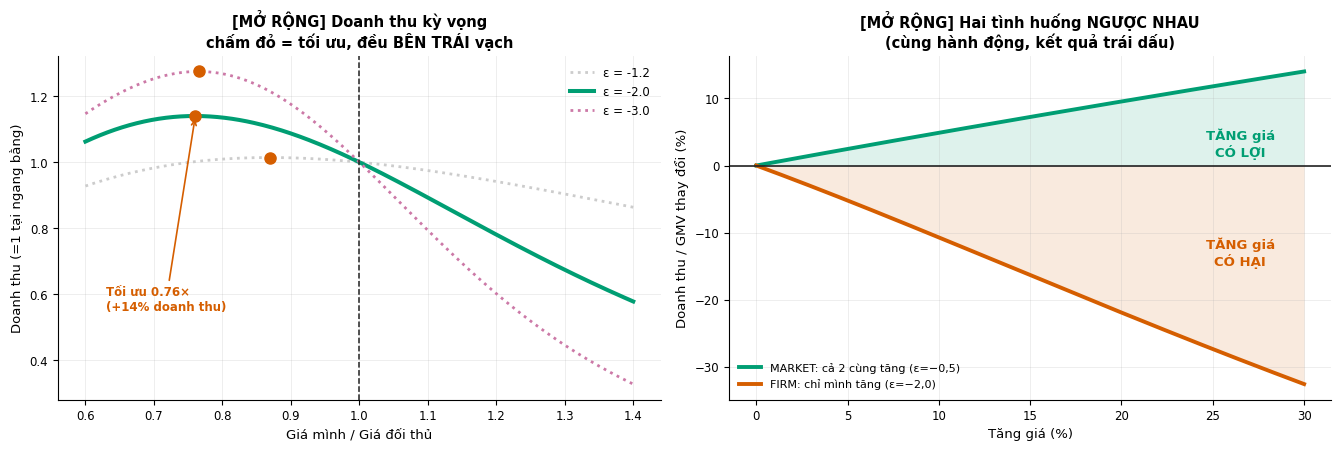

Khong mau thuan — 2 CAU HOI KHAC NHAU:
  'Ca thi truong co nen tang gia?'  -> CO  (khop bang chung GMV +10% cua mentor)
  'Minh co nen ban dat hon doi thu?' -> KHONG (khach chay sang doi thu)


In [14]:
# ═════════ HINH AC6 — MO RONG: doanh thu ═════════
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))
rr = np.linspace(0.6, 1.4, 300)

for e, col, lw in zip(EPS_F, [LIGHT, GREEN, PURPLE], [2, 2.9, 2]):
    R = rr * P_accept(rr, e); R = R / (1.0 * P_accept(1.0, e))
    ax[0].plot(rr, R, color=col, lw=lw, ls="-" if e == EPS_CHINH else ":", label=f"ε = {e}")
    i = int(np.argmax(R)); ax[0].plot(rr[i], R[i], "o", color=RED, ms=8, zorder=6)
R2 = rr * P_accept(rr, EPS_CHINH); R2 = R2 / (1.0 * P_accept(1.0, EPS_CHINH))
i2 = int(np.argmax(R2))
ax[0].annotate(f"Tối ưu {rr[i2]:.2f}×\n(+{(R2[i2]-1)*100:.0f}% doanh thu)",
               xy=(rr[i2], R2[i2]), xytext=(0.63, 0.55), fontsize=8.5, fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.2))
ax[0].axvline(1.0, color=INK, lw=1.1, ls="--")
ax[0].set_xlabel("Giá mình / Giá đối thủ"); ax[0].set_ylabel("Doanh thu (=1 tại ngang bằng)")
ax[0].set_title("[MỞ RỘNG] Doanh thu kỳ vọng\nchấm đỏ = tối ưu, đều BÊN TRÁI vạch", fontweight="bold")
ax[0].legend(frameon=False)

p2 = np.linspace(0, 0.30, 200)
y_m = ((1+p2)**(1+(-0.5)) - 1)*100
y_f = np.array([((1+p)*P_accept(1+p, EPS_CHINH)/(1.0*P_accept(1.0, EPS_CHINH)) - 1)*100 for p in p2])
ax[1].plot(p2*100, y_m, color=GREEN, lw=2.8, label="MARKET: cả 2 cùng tăng (ε=−0,5)")
ax[1].plot(p2*100, y_f, color=RED, lw=2.8, label="FIRM: chỉ mình tăng (ε=−2,0)")
ax[1].fill_between(p2*100, 0, y_m, color=GREEN, alpha=0.13, lw=0)
ax[1].fill_between(p2*100, 0, y_f, color=RED, alpha=0.13, lw=0)
ax[1].axhline(0, color=INK, lw=1.2)
ax[1].text(26.5, 3.2, "TĂNG giá\nCÓ LỢI", color=GREEN, fontsize=9.5, fontweight="bold",
           ha="center", va="center")
ax[1].text(26.5, -13, "TĂNG giá\nCÓ HẠI", color=RED, fontsize=9.5, fontweight="bold",
           ha="center", va="center")
ax[1].set_xlabel("Tăng giá (%)"); ax[1].set_ylabel("Doanh thu / GMV thay đổi (%)")
ax[1].set_title("[MỞ RỘNG] Hai tình huống NGƯỢC NHAU\n(cùng hành động, kết quả trái dấu)",
                fontweight="bold")
ax[1].legend(frameon=False, fontsize=8, loc="lower left")

plt.tight_layout(); plt.savefig(HINH / "AC6_morong_doanhthu.png"); plt.show()
print("Khong mau thuan — 2 CAU HOI KHAC NHAU:")
print("  'Ca thi truong co nen tang gia?'  -> CO  (khop bang chung GMV +10% cua mentor)")
print("  'Minh co nen ban dat hon doi thu?' -> KHONG (khach chay sang doi thu)")

---

# ⚠️ PHẦN 8 — MỞ RỘNG: mô phỏng đầu-cuối trên 864.360 chuyến

> **Vẫn là phần mở rộng, mentor không yêu cầu.**

Nối model giá đã train (tuần 2) với acceptance model, chạy trên toàn bộ tập test:

```
① Model giá  →  p̂     ② Acceptance  →  P     ③ Tối ưu  →  p*     ④ Đối chiếu giá thật
```

**Điểm mấu chốt:** lúc **quyết định** dùng `p̂` (chưa biết giá thật), nhưng lúc khách **cân nhắc**
thì so với `p_thật`. Chênh lệch này tạo ra **chi phí của việc dự đoán sai**.

In [15]:
ar = pd.read_parquet("../evaluation/pred_hybrid_cu.parquet")
ar = ar[ar.algo == "HistGB"].reset_index(drop=True)
print(f"Nap du doan model gia: {len(ar):,} chuyen (tap test)")

sim = pd.DataFrame({
    "gia_that": ar.target_shown_price.astype("float64"),
    "gia_dudoan": ar.hybrid_pred.astype("float64"),
    "persistence": ar.latest_observed_price.astype("float64"),
    "gio": ar.gio_vn.astype(int),
})
sim["mua"] = ar.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"]).values
sim["dich_WTP"] = sim.gio.map(DICH_GIO.to_dict()) + np.where(sim.mua, DICH_MUA, 0.0)
sim["gia_khuyennghi"] = R_STAR * (1 + sim.dich_WTP) * sim.gia_dudoan
sim["P_chapnhan"] = P_accept(sim.gia_khuyennghi / sim.gia_that, EPS_CHINH, dich_WTP=sim.dich_WTP)
sim["doanhthu"] = sim.gia_khuyennghi * sim.P_chapnhan
sim["lech_pct"] = sim.gia_khuyennghi / sim.gia_that - 1

print(f"Sai so model gia: MAE {np.abs(sim.gia_dudoan-sim.gia_that).mean():,.0f} d "
      f"| MAPE {(np.abs(sim.gia_dudoan-sim.gia_that)/sim.gia_that).mean()*100:.2f}%\n")
print(f"{'Gia doi thu THAT (TB)':<32}: {sim.gia_that.mean():>11,.0f} d")
print(f"{'Gia doi thu DU DOAN (TB)':<32}: {sim.gia_dudoan.mean():>11,.0f} d")
print(f"{'Gia KHUYEN NGHI (TB)':<32}: {sim.gia_khuyennghi.mean():>11,.0f} d")
print(f"{'Do lech vs gia that':<32}: {(sim.gia_khuyennghi-sim.gia_that).mean():>11,.0f} d "
      f"({sim.lech_pct.mean()*100:+.1f}%)")

Nap du doan model gia: 864,360 chuyen (tap test)
Sai so model gia: MAE 18,048 d | MAPE 14.74%

Gia doi thu THAT (TB)           :     122,986 d
Gia doi thu DU DOAN (TB)        :     120,688 d
Gia KHUYEN NGHI (TB)            :      96,196 d
Do lech vs gia that             :     -26,790 d (-20.1%)


In [16]:
# --- Phan ra do lech: bao nhieu la CHU Y, bao nhieu la SAI SO ---
sim["tp_chienluoc"] = np.log(R_STAR)
sim["tp_boicanh"]   = np.log1p(sim.dich_WTP)
sim["tp_saiso"]     = np.log(sim.gia_dudoan / sim.gia_that)
assert np.allclose(sim.tp_chienluoc + sim.tp_boicanh + sim.tp_saiso,
                   np.log(sim.gia_khuyennghi/sim.gia_that), atol=1e-9)

print("PHAN RA DO LECH so voi gia that:")
display(pd.DataFrame({
    "Thanh phan": ["Chien luoc (ban re hon)", "Boi canh (gio/thoi tiet)",
                   "Sai so du doan gia", "TONG"],
    "TB (%)": [(np.exp(sim.tp_chienluoc.mean())-1)*100, (np.exp(sim.tp_boicanh.mean())-1)*100,
               (np.exp(sim.tp_saiso.mean())-1)*100,
               (np.exp(np.log(sim.gia_khuyennghi/sim.gia_that).mean())-1)*100],
    "Do lech chuan (%)": [0.0, sim.tp_boicanh.std()*100, sim.tp_saiso.std()*100,
                          np.log(sim.gia_khuyennghi/sim.gia_that).std()*100],
    "Ban chat": ["CHU Y", "CHU Y", "SAI SO - can giam", ""],
}).round(2))
print("-> ~97% do lech la CHU Y. Sai so du doan gan nhu khong lech he thong (-0.1%),")
print("   nhung chiem phan lon BIEN THIEN -> sai lung tung theo tung chuyen.\n")

# --- So sanh chinh sach ---
def danh_gia(g, ten):
    P = P_accept(g / sim.gia_that, EPS_CHINH, dich_WTP=sim.dich_WTP)
    return {"Chinh sach": ten, "Gia TB (d)": g.mean(),
            "P(chap nhan) %": P.mean()*100, "Doanh thu ky vong (d)": (g*P).mean()}

ket = pd.DataFrame([
    danh_gia(R_STAR*(1+sim.dich_WTP)*sim.gia_that, "1. Oracle (biet truoc gia that)"),
    danh_gia(sim.gia_khuyennghi,                   "2. DE XUAT (dung p_hat)"),
    danh_gia(sim.gia_that,                         "3. Bam gia that (tham chieu)"),
    danh_gia(sim.gia_dudoan,                       "4. Bam gia du doan"),
    danh_gia(sim.persistence,                      "5. Persistence"),
])
display(ket.round(1))

dt_o, dt_d = ket.iloc[0]["Doanh thu ky vong (d)"], ket.iloc[1]["Doanh thu ky vong (d)"]
print("=" * 66)
print(f"CHI PHI CUA VIEC DU DOAN SAI: {dt_o-dt_d:,.0f} d/chuyen ({(1-dt_d/dt_o)*100:.2f}%)")
print("=" * 66)
print("-> Day la GIA TRI KINH TE cua viec cai thien model gia, quy ra tien.")

PHAN RA DO LECH so voi gia that:


,Thanh phan,TB (%),Do lech chuan (%),Ban chat
0,Chien luoc (ban re hon),-24.02,0.00,CHU Y
1,Boi canh (gio/thoi tiet),2.92,11.37,CHU Y
2,Sai so du doan gia,-0.14,18.40,SAI SO - can giam
3,TONG,-21.91,21.55,


-> ~97% do lech la CHU Y. Sai so du doan gan nhu khong lech he thong (-0.1%),
   nhung chiem phan lon BIEN THIEN -> sai lung tung theo tung chuyen.



,Chinh sach,Gia TB (d),P(chap nhan) %,Doanh thu ky vong (d)
0,1. Oracle (biet truoc gia that),98041.7,75.0,73535.7
1,2. DE XUAT (dung p_hat),96195.7,72.9,70154.4
2,3. Bam gia that (tham chieu),122986.0,53.0,66861.2
3,4. Bam gia du doan,120687.8,52.8,65175.9
4,5. Persistence,122906.2,52.2,60066.3


CHI PHI CUA VIEC DU DOAN SAI: 3,381 d/chuyen (4.60%)
-> Day la GIA TRI KINH TE cua viec cai thien model gia, quy ra tien.


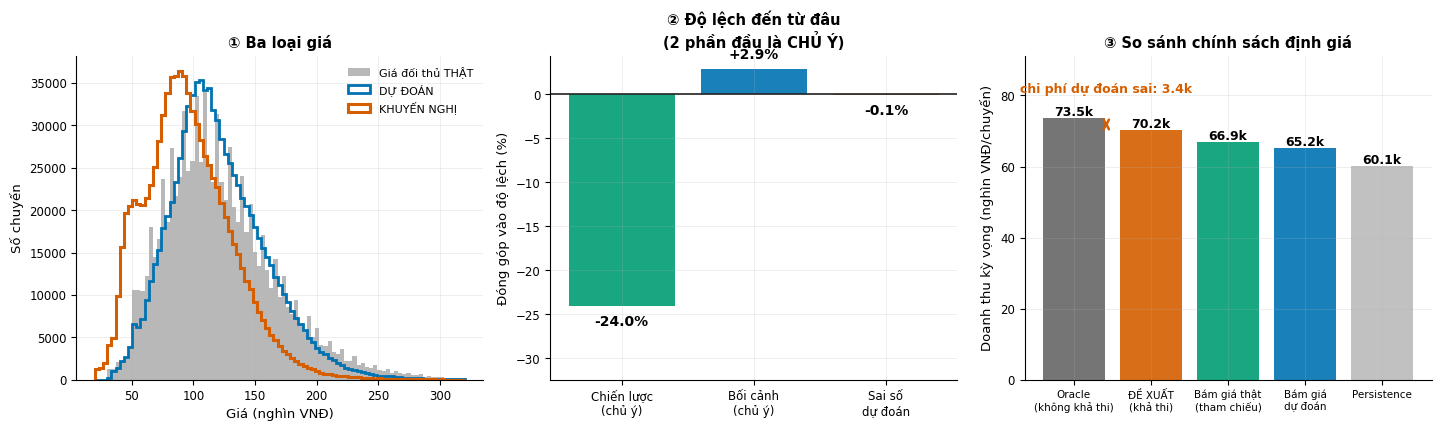

In [17]:
# ═════════ HINH AC7 — MO RONG: mo phong ═════════
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

bins = np.linspace(20, 320, 90)
ax[0].hist(sim.gia_that/1000, bins=bins, color=INK, alpha=0.32, lw=0, label="Giá đối thủ THẬT")
ax[0].hist(sim.gia_dudoan/1000, bins=bins, histtype="step", color=BLUE, lw=2, label="DỰ ĐOÁN")
ax[0].hist(sim.gia_khuyennghi/1000, bins=bins, histtype="step", color=RED, lw=2.2, label="KHUYẾN NGHỊ")
ax[0].set_xlabel("Giá (nghìn VNĐ)"); ax[0].set_ylabel("Số chuyến")
ax[0].set_title("① Ba loại giá", fontweight="bold"); ax[0].legend(frameon=False, fontsize=8)

tp = [(np.exp(sim.tp_chienluoc.mean())-1)*100, (np.exp(sim.tp_boicanh.mean())-1)*100,
      (np.exp(sim.tp_saiso.mean())-1)*100]
b_ = ax[1].bar(range(3), tp, color=[GREEN, BLUE, RED], alpha=0.9)
for bb, v in zip(b_, tp):
    ax[1].text(bb.get_x()+bb.get_width()/2, v + (1.1 if v >= 0 else -2.2), f"{v:+.1f}%",
               ha="center", fontsize=10, fontweight="bold")
ax[1].axhline(0, color=INK, lw=1.2)
ax[1].set_xticks(range(3))
ax[1].set_xticklabels(["Chiến lược\n(chủ ý)", "Bối cảnh\n(chủ ý)", "Sai số\ndự đoán"], fontsize=8.5)
ax[1].set_ylabel("Đóng góp vào độ lệch (%)")
ax[1].set_title("② Độ lệch đến từ đâu\n(2 phần đầu là CHỦ Ý)", fontweight="bold")
ax[1].set_ylim(min(tp)*1.35, max(max(tp)*1.5, 4))

ten_cs = ["Oracle\n(không khả thi)", "ĐỀ XUẤT\n(khả thi)", "Bám giá thật\n(tham chiếu)",
          "Bám giá\ndự đoán", "Persistence"]
dt = ket["Doanh thu ky vong (d)"].values / 1000
b2 = ax[2].bar(range(5), dt, color=[MUT, RED, GREEN, BLUE, "#BBBBBB"], alpha=0.9)
for bb, v in zip(b2, dt):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+0.7, f"{v:.1f}k", ha="center",
               fontsize=9, fontweight="bold")
ax[2].annotate("", xy=(0.42, dt[1]), xytext=(0.42, dt[0]),
               arrowprops=dict(arrowstyle="<->", color=RED, lw=1.8))
ax[2].text(0.42, dt[0]*1.10, f"chi phí dự đoán sai: {dt[0]-dt[1]:.1f}k",
           fontsize=9, fontweight="bold", color=RED, ha="center")
ax[2].set_xticks(range(5)); ax[2].set_xticklabels(ten_cs, fontsize=7.5)
ax[2].set_ylabel("Doanh thu kỳ vọng (nghìn VNĐ/chuyến)")
ax[2].set_title("③ So sánh chính sách định giá", fontweight="bold")
ax[2].set_ylim(0, max(dt)*1.24)

plt.tight_layout(); plt.savefig(HINH / "AC7_morong_mophong.png"); plt.show()

---

# PHẦN 8b — Các hướng đã THỬ và LOẠI TRỪ

Trước khi chốt kiến trúc logit, đã thử và loại 8 hướng khác. Ghi lại để không ai phải làm lại.

| Hướng | Vì sao loại | Bằng chứng |
|---|---|---|
| **Supervised học từ nhãn thật** | Không có nhãn | `booking_or_completion_outcomes_generated = False`; rà 251 cột → 0 kết quả |
| **Unsupervised** | Acceptance không tồn tại dưới dạng nào trong dữ liệu | Không phải "chưa gắn nhãn" mà là "cơ chế không có" |
| **Rule-based weak labeling** ⭐ | **Vòng tròn logic** | AUC = 1,0000 → bỏ `price_gap` còn **0,4995**; ε ngụ ý = 0 hoặc −44 |
| **Proxy label từ cột khác** | Không cột nào phù hợp | Rà hết 70 cột của bảng forecasting |
| **PU learning** | Cần ít nhất vài ca dương | Quan sát được **0** ca chấp nhận |
| **Đảo ngược quy tắc định giá** | Surge sinh cơ học, không phải tối ưu hoá | Công thức `m = f(imbalance)` |
| **SMM / indirect inference** | Mô-men quan sát không chứa thông tin acceptance | Placebo test: tương quan 0,004 |
| **Personalized model** | Không có `customer_id` | `personalized_wrapper_enabled = False` (có 20.000 khách nhưng không xuất) |

## Chi tiết hướng rule-based weak labeling

Đây là hướng được đề xuất nhiều nhất nên đã kiểm chứng kỹ (xem `05_thu_nghiem_pseudo_label.ipynb`).

**Luật thử nghiệm:** `gap ≤ −15% → 1.0` · `−15%→5% → 0.7` · `5%→10% → 0.3` · `>10% → 0.0`

| Thí nghiệm | Kết quả | Ý nghĩa |
|---|---|---|
| Train đủ 13 feature | AUC **1,0000** | Rò rỉ — nhãn là hàm tất định của feature |
| Feature importance | `price_gap` chiếm **100,0%** | 12 feature còn lại ≈ 0 |
| **Bỏ `price_gap`** | AUC **0,4995** | **Sụp về mức đoán bừa** |

**Elasticity ngụ ý của luật:**

| Khoảng gap | ε ngụ ý | Nghĩa |
|---|---:|---|
| 0% → 4% | **0,0** | Khách hoàn toàn không phản ứng với giá |
| 4% → 6% | **−44,5** | Khách đổi ý hoàn toàn chỉ vì lệch 2% |

Cả hai đều phi thực tế (dải hợp lý: −1 → −4).

> **Kết luận:** luật bậc thang cần **6 tham số bịa ra**, cho elasticity phi lý, và nguỵ trang thành
> ML. Logit chỉ cần **2 tham số**, có cơ sở lý thuyết, và trung thực về bản chất giả định.
>
> ⚠️ Weak labeling **không sai về nguyên tắc** — nó rất mạnh khi nhãn yếu đến từ **nguồn độc lập**
> với feature. Nếu mentor cấp bộ có `outcome`, hướng này trở nên hoàn toàn hợp lý.

---

# PHẦN 9 — Kết luận & hạn chế

## ✅ Trả lời mentor (Phần 3, 4, 6)

| Model | Câu hỏi | Trả lời |
|---|---|---|
| **1** | Biết **giá đối thủ** → tăng hay giảm? | **GIẢM** khi giá mình cao hơn. Tăng 10% → chấp nhận 50% → 40,6% (−9,4 điểm %) |
| **2** | Biết **thời tiết** → tăng hay giảm? | **TĂNG** khi mưa (+4,5 điểm %). Nhưng **giờ mạnh hơn ~8 lần** |

**3 kết luận vững** trên toàn dải elasticity (3/3): giá cao hơn → chấp nhận giảm · mưa → chấp nhận
tăng · giờ mạnh hơn thời tiết.

## ⚠️ Phần mở rộng (Phần 7, 8) — không được yêu cầu

Giá tối ưu ~0,76× giá đối thủ · chính sách đề xuất +5% doanh thu so với bám giá đối thủ · chi phí
do model giá chưa hoàn hảo ~3.400đ/chuyến.

## Hạn chế phải nêu khi báo cáo

| Hạn chế | Chi tiết |
|---|---|
| **Không có nhãn thật** | Toàn bộ là mô phỏng dưới giả định, chưa kiểm chứng bằng hành vi khách |
| **`P₀ = 0,5` là quy ước** | Tham số **nhạy nhất**, không kiểm chứng được từ dữ liệu |
| **`ε_firm` suy gián tiếp** | Từ `ε_market` + thị phần ước tính, cần mentor xác nhận |
| **Global, không cá nhân hoá** | Dữ liệu có `n_customers=20000` nhưng **không xuất ID** (0/251 cột) |
| **Model tĩnh** | Chưa tính phản ứng của đối thủ khi mình giảm giá |
| **Doanh thu là mô phỏng** | Không phải doanh thu thật đo được |

> **Cách phát biểu đúng:** *"Dưới giả định elasticity ε ∈ [−1,2; −3,0], khả năng chấp nhận giảm
> khoảng 9 điểm % khi tăng giá 10% so với đối thủ, và tăng ~4,5 điểm % khi trời mưa."* — luôn kèm
> mệnh đề *"dưới giả định"*.

## Hình đã sinh ra

| Hình | Nội dung | Phạm vi |
|---|---|---|
| `AC1` | Dữ liệu đầu vào — tham số đo từ đâu | Nền tảng |
| `AC2` | Cơ chế model logit | Nền tảng |
| `AC3` | **MODEL 1** — chấp nhận theo giá | ✅ Yêu cầu |
| `AC4` | **MODEL 2** — thời tiết & giờ | ✅ Yêu cầu |
| `AC5` | Bảng tra cứu giá × khung giờ | ✅ Yêu cầu |
| `AC6` | Doanh thu & giá tối ưu | ⚠️ Mở rộng |
| `AC7` | Mô phỏng đầu-cuối | ⚠️ Mở rộng |